## Michelle A. Gómez López - 741902


## 24/08/2026
__________

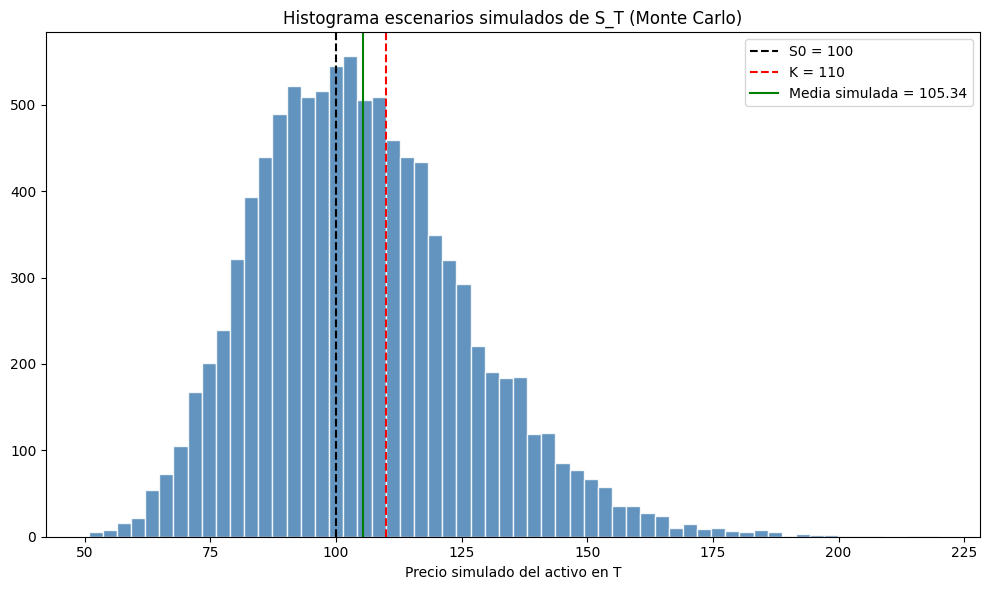

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(32)

S0 = 100       # precio inicial del activo
K = 110        # precio de ejercicio (strike)
r = 0.05       # tasa libre de riesgo
vol = 0.20     # volatilidad
T = 1          # plazo en anios
M = int(10e3)  # numero de simulaciones (10,000)

# --- Simulacion Monte Carlo (movimiento geometrico browniano) ---
Z = np.random.standard_normal(M)
ST = S0 * np.exp((r - 0.5 * vol**2) * T + vol * np.sqrt(T) * Z)

#  Histograma de los escenarios simulados
plt.figure(figsize=(10, 6))
plt.hist(ST, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
plt.axvline(S0, color="black", linestyle="--", linewidth=1.5, label=f"S0 = {S0}")
plt.axvline(K, color="red", linestyle="--", linewidth=1.5, label=f"K = {K}")
plt.axvline(ST.mean(), color="green", linestyle="-", linewidth=1.5, label=f"Media simulada = {ST.mean():.2f}")
plt.title(f"Histograma escenarios simulados de S_T (Monte Carlo)")
plt.xlabel("Precio simulado del activo en T")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
# con max(ST - K, 0)
payoff_call = np.maximum(ST - K, 0)
precio_call_mc = np.exp(-r * T) * payoff_call.mean()

# Error estandar de la estimacion Monte Carlo
error_std_call = np.exp(-r * T) * payoff_call.std() / np.sqrt(M)

print(f"Precio call (Monte Carlo): {precio_call_mc:.4f}  (+/- {error_std_call:.4f})")

# Black-Scholes
d1 = (np.log(S0 / K) + (r + 0.5 * vol**2) * T) / (vol * np.sqrt(T))
d2 = d1 - vol * np.sqrt(T)

precio_call_bs = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print(f"\nPrecio call (Black-Scholes): {precio_call_bs:.4f}")


Precio call (Monte Carlo): 6.1628  (+/- 0.1175)

Precio call (Black-Scholes): 6.0401
